# Price Prediction Model
Condensed version - just the pieces that actually matter for the final model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/raw/real_estate_master.csv")
df = df.drop(columns=(df.isna().mean()[lambda s: s > 0.75]).index.tolist())


(12359, 27)


In [ ]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["area"] = pd.to_numeric(df["area"], errors="coerce")
df["security_deposit"] = pd.to_numeric(df["security_deposit"], errors="coerce")
df = df.dropna(subset=["price", "area"])
df = df[(df["price"] > 0) & (df["area"] > 0)]

In [ ]:
def cap(d, col, g):
    lo, hi = d.groupby(g)[col].transform("quantile", 0.01), d.groupby(g)[col].transform("quantile", 0.99)
    return d[(d[col] >= lo) & (d[col] <= hi)]
df = cap(df, "price", "property_type")
df = cap(df, "area", "property_type")

In [ ]:
amenity_cols = ["Lift(s)", "Full Power Backup", "24 X 7 Security", "Children's play area",
                "Club House", "Gymnasium", "Swimming Pool", "Sports Facility",
                "Jogging Track", "Landscaped Gardens"]
for c in amenity_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
for c in ["facing", "status", "location", "city", "property_type"]:
    df[c] = df[c].astype(str).str.strip().str.title().replace({"Nan": np.nan})
df[["facing", "status", "location"]] = df[["facing", "status", "location"]].fillna("Unknown")
df["Car Parking"] = pd.to_numeric(df["Car Parking"], errors="coerce").fillna(0)
df["amenity_count"] = df[amenity_cols].sum(axis=1)
df = df.drop_duplicates()
print(df.shape)

## features - location target-encoded (620 uniques), a few keywords pulled from description

In [ ]:
df["description"] = df["description"].fillna("")
desc = df["description"].str.lower()
for name, kw in {"desc_has_metro":"metro","desc_has_luxury":"luxury","desc_has_premium":"premium",
                  "desc_has_gated":"gated","desc_has_corner_plot":"corner plot","desc_has_spacious":"spacious"}.items():
    df[name] = desc.str.contains(kw, regex=False).astype(int)


(9887, 41)

In [ ]:
cat_cols = ["city", "property_type", "facing", "status"]
desc_cols = [c for c in df.columns if c.startswith("desc_has_")]
num_cols = [c for c in df.columns if c not in cat_cols + desc_cols +
            ["price", "location", "description", "price_currency"]]

X = model_df[feature_cols + ["location"]]
y, y_price = model_df["log_price"], model_df["price"]
X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(X, y, y_price, test_size=0.2, random_state=42)

In [ ]:
# target-encode location using train only (smoothed so rare locations don't get wild values)
stats = X_train.assign(log_price=y_train).groupby("location")["log_price"].agg(["mean", "count"])
global_mean = y_train.mean()
loc_encoding = (stats["mean"] * stats["count"] + global_mean * 10) / (stats["count"] + 10)
X_train = X_train.assign(location_encoded=X_train["location"].map(loc_encoding)).drop(columns=["location"])
X_test = X_test.assign(location_encoded=X_test["location"].map(loc_encoding).fillna(global_mean)).drop(columns=["location"])


In [ ]:
num_cols_final = num_cols + ["location_encoded"]
imputer = KNNImputer(n_neighbors=5)
X_train[num_cols_final] = imputer.fit_transform(X_train[num_cols_final])
X_test[num_cols_final] = imputer.transform(X_test[num_cols_final])


In [ ]:
scaler = StandardScaler()
X_train[num_cols_final] = scaler.fit_transform(X_train[num_cols_final])
X_test[num_cols_final] = scaler.transform(X_test[num_cols_final])
feature_cols = list(X_trai.ncolumns)
X_train.shape

## training

Note on the clipping below: fitting on log(price) and converting back with `expm1()`
can blow up badly if a model extrapolates even a little - a log-price of 20 instead of
15 turns into hundreds of millions of rupees after expm1, and that one point alone can
wreck R2. Clipping predictions to the training range before converting back fixes it -
this is what took Linear Regression from R2=-2.39 to +0.31.

In [3]:
log_min, log_max = y_train.min(), y_train.max()

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred_price = np.expm1(np.clip(model.predict(X_test), log_min, log_max))
    r2 = r2_score(price_test, pred_price)
    mae = mean_absolute_error(price_test, pred_price)
    print(f"{name}: MAE={mae:,.0f}  R2={r2:.3f}")
    return model, r2, pred_price

lr_model, lr_r2, _ = evaluate(LinearRegression(), "Linear Regression")

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {"n_estimators":[100,200], "max_depth":[10,20]}, cv=2, scoring="r2")
rf_grid.fit(X_train, y_train)
rf_model, rf_r2, rf_pred = evaluate(rf_grid.best_estimator_, "Tuned Random Forest")

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42, max_depth=3), {"n_estimators":[100,150], "learning_rate":[0.05,0.1]}, cv=2, scoring="r2")
gb_grid.fit(X_train, y_train)
gb_model, gb_r2, gb_pred = evaluate(gb_grid.best_estimator_, "Tuned Gradient Boosting")

best_model, best_pred, best_name = max(
    [(lr_model, None, "Linear Regression"), (rf_model, rf_pred, "Tuned Random Forest"), (gb_model, gb_pred, "Tuned Gradient Boosting")],
    key=lambda t: r2_score(price_test, np.expm1(np.clip(t[0].predict(X_test), log_min, log_max)))
)
print("best:", best_name)


Linear Regression: MAE=2,440,122  R2=0.312


Tuned Random Forest: MAE=1,321,338  R2=0.818


Tuned Gradient Boosting: MAE=1,625,017  R2=0.799
best: Tuned Random Forest


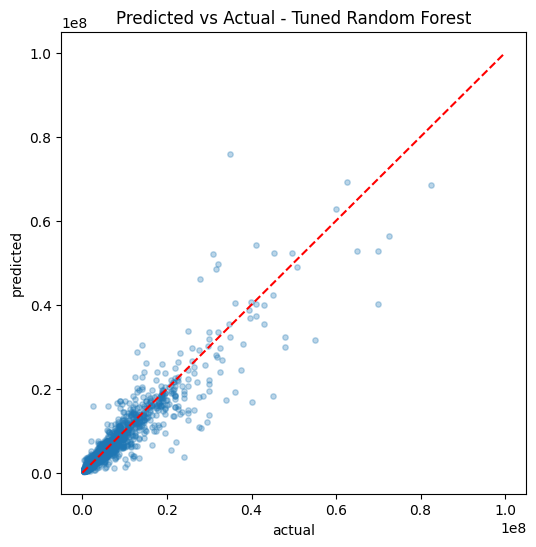

In [4]:
pred_price = np.expm1(np.clip(best_model.predict(X_test), log_min, log_max))
plt.figure(figsize=(6,6))
idx = np.random.choice(len(price_test), min(2000, len(price_test)), replace=False)
plt.scatter(price_test.values[idx], pred_price[idx], alpha=0.3, s=15)
plt.plot([0, price_test.max()], [0, price_test.max()], "r--")
plt.xlabel("actual"); plt.ylabel("predicted"); plt.title(f"Predicted vs Actual - {best_name}")
plt.show()


In [5]:
import joblib
joblib.dump(best_model, "../models/price_model.pkl")
joblib.dump(scaler, "../models/price_scaler.pkl")
joblib.dump(imputer, "../models/price_imputer.pkl")
joblib.dump(feature_cols, "../models/price_model_columns.pkl")
joblib.dump(num_cols_final, "../models/price_numeric_columns.pkl")
joblib.dump(loc_encoding.to_dict(), "../models/price_location_encoding.pkl")
joblib.dump(global_mean, "../models/price_location_global_mean.pkl")
joblib.dump((log_min, log_max), "../models/price_log_clip_range.pkl")
print("saved:", best_name)


saved: Tuned Random Forest
